In [1]:
import os

DATASET_PATH = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset path not found: {DATASET_PATH}\n"
        "If you're not running on Kaggle, update DATASET_PATH to point "
        "to your local copy of the TrashNet 'dataset-resized' folder."
    )

print(os.listdir(DATASET_PATH))


['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [2]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


## ⚙️ Model Config — B0 / B2 / B3

In [3]:
MODEL_NAME = "efficientnet_b0"   # "efficientnet_b0" | "efficientnet_b2" | "efficientnet_b3"

IMG_SIZE_MAP = {
    "efficientnet_b0": 224,
    "efficientnet_b2": 260,
    "efficientnet_b3": 300,
}
IMG_SIZE = IMG_SIZE_MAP[MODEL_NAME]

print("Using model:", MODEL_NAME, "| IMG_SIZE:", IMG_SIZE)


Using model: efficientnet_b0 | IMG_SIZE: 224


In [4]:
from torchvision import transforms

# Data Augmentation أقوى:
# - RandomResizedCrop بدل Resize العادي عشان تنويع أكبر في الزوايا/التقريب
# - RandomRotation أوسع شوية
# - ColorJitter أقوى + Hue
# - RandomAffine (shift/shear بسيط)
# - RandomErasing بعد التطبيع، بيحسن الـ robustness ضد الاحتجاب الجزئي
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
from torchvision.datasets import ImageFolder

# NOTE: no transform passed here on purpose.
# We apply train/val/test transforms separately after splitting,
# so train/val/test don't end up sharing the same transform object.
dataset = ImageFolder(root=DATASET_PATH)

print(dataset.classes)
print("Number of Images:", len(dataset))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Images: 2527


In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2021
252
254


In [7]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    """
    Wraps a Subset and applies its own transform.

    Fixes a subtle bug: since train/val/test all come from random_split()
    on the SAME underlying ImageFolder, doing
    `val_dataset.dataset.transform = test_transform` would silently
    overwrite the transform for train_dataset too (they share the same
    underlying .dataset object). Wrapping each split like this keeps
    the transforms fully independent.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_dataset = TransformSubset(train_dataset, train_transform)
val_dataset = TransformSubset(val_dataset, test_transform)
test_dataset = TransformSubset(test_dataset, test_transform)

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [9]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    efficientnet_b2, EfficientNet_B2_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
)


In [10]:
# DEVICE already set above (cell 2) — kept here only as a sanity check
print("Device:", DEVICE)


Device: cuda


In [11]:
MODEL_BUILDERS = {
    "efficientnet_b0": (efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
    "efficientnet_b2": (efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
    "efficientnet_b3": (efficientnet_b3, EfficientNet_B3_Weights.DEFAULT),
}

builder_fn, weights = MODEL_BUILDERS[MODEL_NAME]
model = builder_fn(weights=weights)

NUM_CLASSES = 6
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]


In [12]:
model = model.to(DEVICE)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


## 🔓 Fine-Tuning — EfficientNetـ classifier

In [13]:
# Freeze everything first, then unfreeze only what we want to fine-tune
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

FINE_TUNE_LAST_N_BLOCKS = 4

feature_blocks = list(model.features.children())
for block in feature_blocks[-FINE_TUNE_LAST_N_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

print(f"Unfroze classifier + last {FINE_TUNE_LAST_N_BLOCKS} feature blocks")


Unfroze classifier + last 4 feature blocks


In [14]:
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable Parameters: {trainable_params:,}")
print(f"Total Parameters: {total_params:,}")

Trainable Parameters: 3,706,574
Total Parameters: 4,015,234


In [15]:
# وده بيقلل overfitting وبيحسن الـ generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


In [16]:
import torch.optim as optim

# Discriminative Learning Rates:
# الطبقات المفكوكة من الـ backbone (pretrained) تاخد LR أقل عشان منكسرش الفيتشرز المتعلمة قبل كده
backbone_params = [
    p for name, p in model.named_parameters()
    if p.requires_grad and "classifier" not in name
]
classifier_params = [
    p for name, p in model.named_parameters()
    if p.requires_grad and "classifier" in name
]

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-4},
        {"params": classifier_params, "lr": 1e-3},
    ],
    weight_decay=1e-4
)


In [17]:
# CosineAnnealingLR بينزل الـ LR بشكل تدريجي (cosine curve) على مدار الـ epochs
# ده بيدي تدريب أنعم من ReduceLROnPlateau وعادة بيوصل لأداء أحسن
EPOCHS = 25  # هنزود العدد لأن عندنا Early Stopping هيوقف التدريب لو مفيش تحسن

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


In [18]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [20]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    running_acc = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [21]:
best_val_loss = float("inf")

EARLY_STOPPING_PATIENCE = 6
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [22]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # CosineAnnealingLR بيتنادى من غير باراميتر (مش زي ReduceLROnPlateau)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[-1]["lr"]

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.4f} | LR: {current_lr:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best Model Saved")
    else:
        epochs_without_improvement += 1
        print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s)")

    print("-"*50)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"⏹️ Early stopping triggered after {epoch+1} epochs")
        break


Epoch 1/25
Train Loss : 1.2503 | Train Acc : 0.6078
Val Loss   : 0.8720 | Val Acc   : 0.8181 | LR: 0.000996
✅ Best Model Saved
--------------------------------------------------
Epoch 2/25
Train Loss : 0.8508 | Train Acc : 0.8201
Val Loss   : 0.7738 | Val Acc   : 0.8175 | LR: 0.000984
✅ Best Model Saved
--------------------------------------------------
Epoch 3/25
Train Loss : 0.7653 | Train Acc : 0.8618
Val Loss   : 0.7122 | Val Acc   : 0.8778 | LR: 0.000965
✅ Best Model Saved
--------------------------------------------------
Epoch 4/25
Train Loss : 0.6840 | Train Acc : 0.9017
Val Loss   : 0.6783 | Val Acc   : 0.8733 | LR: 0.000938
✅ Best Model Saved
--------------------------------------------------
Epoch 5/25
Train Loss : 0.6424 | Train Acc : 0.9214
Val Loss   : 0.6702 | Val Acc   : 0.8728 | LR: 0.000905
✅ Best Model Saved
--------------------------------------------------
Epoch 6/25
Train Loss : 0.6163 | Train Acc : 0.9321
Val Loss   : 0.6554 | Val Acc   : 0.8917 | LR: 0.000865
✅ 

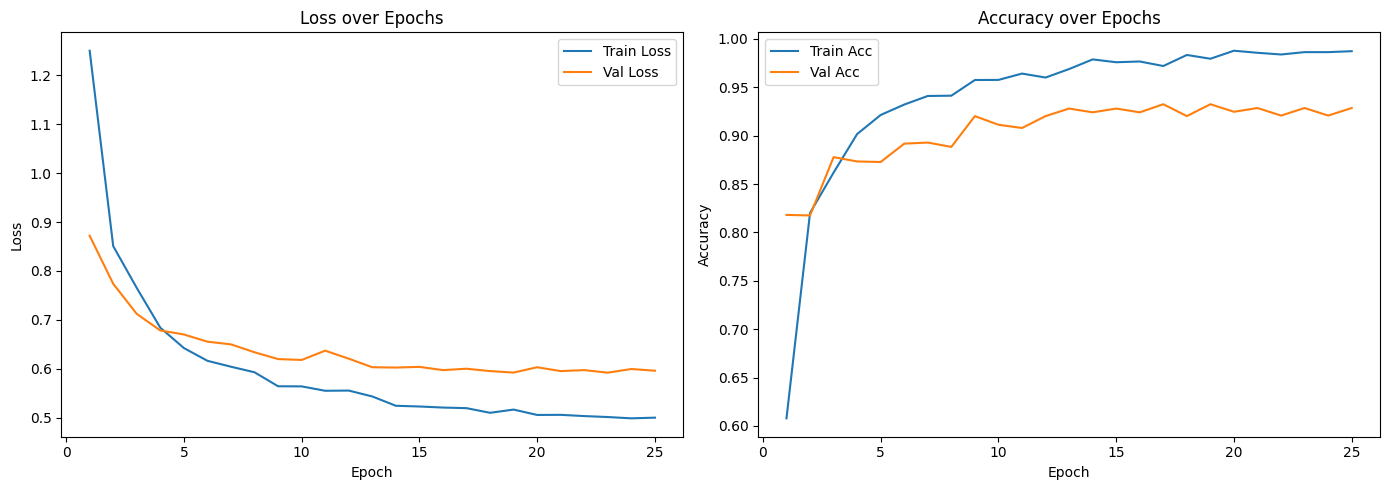

In [23]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)  # يشتغل صح حتى لو Early Stopping وقف بدري

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [24]:
!pip install seaborn

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [27]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [28]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9213
Precision: 0.9224
Recall   : 0.9213
F1 Score : 0.9205


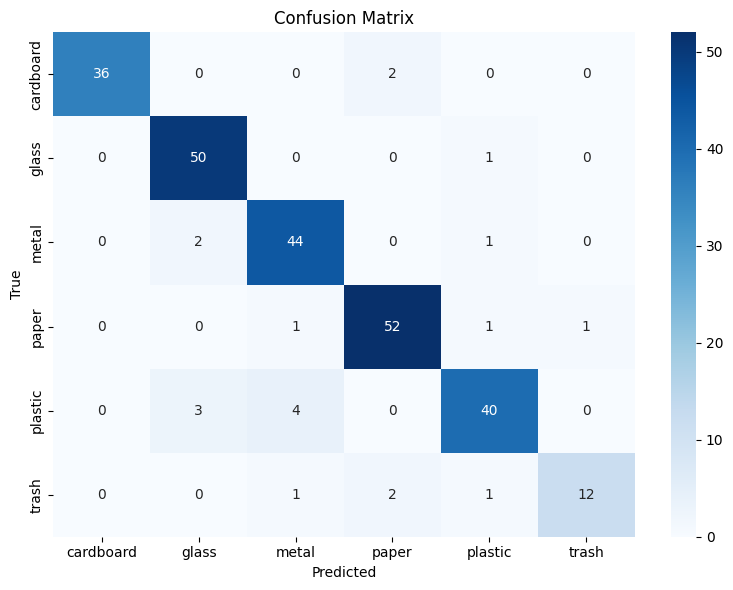

              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        38
       glass       0.91      0.98      0.94        51
       metal       0.88      0.94      0.91        47
       paper       0.93      0.95      0.94        55
     plastic       0.91      0.85      0.88        47
       trash       0.92      0.75      0.83        16

    accuracy                           0.92       254
   macro avg       0.92      0.90      0.91       254
weighted avg       0.92      0.92      0.92       254



In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=dataset.classes))